In [1]:
import pandas as pd

In [7]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
insurance_data["sex"] = insurance_data["sex"].map({"male" : 0 , "female" : 1})
insurance_data["smoker"] = insurance_data["smoker"].map({"yes" : 1 , "no" : 0})

In [9]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [11]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [12]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: xlabel='bmi', ylabel='charges'>

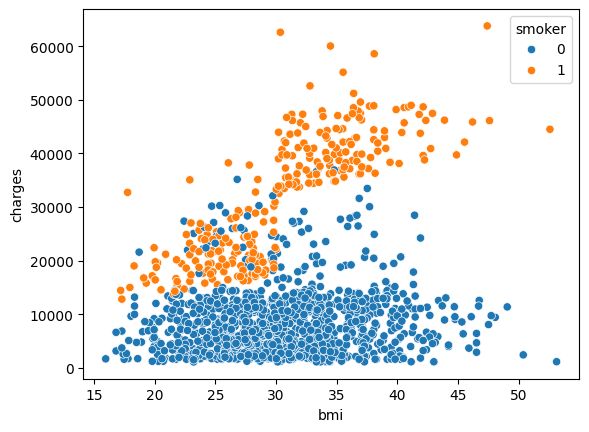

In [14]:
import seaborn as sns

sns.scatterplot(
    x = insurance_data["bmi"],
    y = insurance_data["charges"] ,
    hue = insurance_data["smoker"]
)

In [15]:
X = insurance_data.drop(columns = ["region" , "charges"])
y = insurance_data["charges"]

In [16]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [17]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

### Train-Test-Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

### Train ML Model

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predict Values

In [22]:
y_pred = model.predict(X_test)

In [23]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [24]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [34]:
for y_p , y_t in zip(y_pred , y_test):
    print("Actual - ",y_p , " => " ,"Predicted - ", y_t)
    diff = y_p - y_t
    print(f"Diff = {int(diff)}")

Actual -  8554.817115888562  =>  Predicted -  9095.06825
Diff = -540
Actual -  6973.587467448908  =>  Predicted -  5272.1758
Diff = 1701
Actual -  36798.6041610423  =>  Predicted -  29330.98315
Diff = 7467
Actual -  9417.882823025835  =>  Predicted -  9301.89355
Diff = 115
Actual -  26871.68031081454  =>  Predicted -  33750.2918
Diff = -6878
Actual -  11097.383839380907  =>  Predicted -  4536.259
Diff = 6561
Actual -  145.2760896323216  =>  Predicted -  2117.33885
Diff = -1972
Actual -  16746.168377102906  =>  Predicted -  14210.53595
Diff = 2535
Actual -  747.5341419095312  =>  Predicted -  3732.6251
Diff = -2985
Actual -  11153.675907223997  =>  Predicted -  10264.4421
Diff = 889
Actual -  28518.150165610823  =>  Predicted -  18259.216
Diff = 10258
Actual -  9292.183454208089  =>  Predicted -  7256.7231
Diff = 2035
Actual -  5460.51975119081  =>  Predicted -  3947.4131
Diff = 1513
Actual -  38510.480130033626  =>  Predicted -  46151.1245
Diff = -7640
Actual -  40359.309386042834  => 

### Evaluation Matrics

In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R_square value = " , int(r2 * 100),"%")

R_square value =  78 %


### Feature Engeenering => transforming data

#### One dot encoding => split data in columns

In [35]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [38]:
X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]


X = pd.get_dummies(X , columns = ["region"] , drop_first = False , dtype = int)

In [39]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,0,1
1,18,0,33.770,1,0,0,0,1,0
2,28,0,33.000,3,0,0,0,1,0
3,33,0,22.705,0,0,0,1,0,0
4,32,0,28.880,0,0,0,1,0,0


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
for y_p , y_t in zip(y_pred , y_test):
    print("Actual - ",y_p , " => " ,"Predicted - ", y_t)
    diff = y_p - y_t
    print(f"Diff = {int(diff)}")

Actual -  8969.550274436171  =>  Predicted -  9095.06825
Diff = -125
Actual -  7068.747442870872  =>  Predicted -  5272.1758
Diff = 1796
Actual -  36858.41091154615  =>  Predicted -  29330.98315
Diff = 7527
Actual -  9454.67850053363  =>  Predicted -  9301.89355
Diff = 152
Actual -  26973.17345656347  =>  Predicted -  33750.2918
Diff = -6777
Actual -  10864.113164237306  =>  Predicted -  4536.259
Diff = 6327
Actual -  170.28084136501093  =>  Predicted -  2117.33885
Diff = -1947
Actual -  16903.4502866194  =>  Predicted -  14210.53595
Diff = 2692
Actual -  1092.430936141216  =>  Predicted -  3732.6251
Diff = -2640
Actual -  11218.343183516356  =>  Predicted -  10264.4421
Diff = 953
Actual -  28101.684552669984  =>  Predicted -  18259.216
Diff = 9842
Actual -  9377.734602045193  =>  Predicted -  7256.7231
Diff = 2121
Actual -  5263.059517901982  =>  Predicted -  3947.4131
Diff = 1315
Actual -  38416.04221106744  =>  Predicted -  46151.1245
Diff = -7735
Actual -  40255.823392844584  =>  P

In [45]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R_square value = " , r2 * 100,"%")

R_square value =  78.35929767120723 %
